# Customer Churn Prediction
## Feature Engineering and Model Preparation

In [77]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [78]:
BASE_DIR = os.path.abspath("..")

customers = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "customers_clean.csv"
    )
)

products = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "products_clean.csv"
    )
)

orders = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "orders_clean.csv"
    )
)

order_items = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "order_items_clean.csv"
    )
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [79]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

In [80]:
orders.head()

,order_id,customer_id,order_date,payment_method,shipping_city,shipping_state,order_status
0,1,762,2025-05-07,Cash on Delivery,Hyderabad,Telangana,Delivered
1,2,3923,2024-04-08,Credit Card,Ludhiana,Punjab,Delivered
2,3,3374,2024-05-18,Debit Card,Gurgaon,Haryana,Delivered
3,4,2378,2024-07-03,Credit Card,Kolkata,West Bengal,Delivered
4,5,3014,2023-01-15,UPI,Chandigarh,Chandigarh,Returned


In [81]:
sales_ml = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

sales_ml = sales_ml.merge(
    products,
    on="product_id",
    how="inner"
)

sales_ml.head()

,order_id,customer_id,order_date,payment_method,shipping_city,shipping_state,order_status,order_item_id,product_id,quantity,discount,product_name,category,sub_category,unit_cost,unit_price,profit_per_unit,profit_margin
0,1,762,2025-05-07,Cash on Delivery,Hyderabad,Telangana,Delivered,1,261,4,0.05,Outdoor Product 261,Sports,Outdoor,14558.51,19377.28,4818.77,0.248681
1,1,762,2025-05-07,Cash on Delivery,Hyderabad,Telangana,Delivered,2,33,4,0.15,Headphones Product 33,Electronics,Headphones,7868.38,9567.77,1699.39,0.177616
2,1,762,2025-05-07,Cash on Delivery,Hyderabad,Telangana,Delivered,3,35,1,0.15,Headphones Product 35,Electronics,Headphones,7874.65,9662.54,1787.89,0.185033
3,1,762,2025-05-07,Cash on Delivery,Hyderabad,Telangana,Delivered,4,106,2,0.00,Decor Product 106,Home,Decor,15189.37,21936.23,6746.86,0.307567
4,2,3923,2024-04-08,Credit Card,Ludhiana,Punjab,Delivered,5,6,2,0.10,Smartphones Product 6,Electronics,Smartphones,26094.33,36811.75,10717.42,0.291141


In [82]:
sales_ml["revenue"] = (
    sales_ml["unit_price"]
    * sales_ml["quantity"]
    * (1 - sales_ml["discount"])
)

sales_ml["profit"] = (
    sales_ml["revenue"]
    - (
        sales_ml["unit_cost"]
        * sales_ml["quantity"]
    )
)

In [83]:
max_date = sales_ml["order_date"].max()

min_date = sales_ml["order_date"].min()

print("First date:", min_date)
print("Last date:", max_date)

First date: 2023-01-01 00:00:00
Last date: 2025-12-31 00:00:00


In [84]:
cutoff_date = min_date + (
    max_date - min_date
) * 0.80

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2025-05-26 00:00:00


In [85]:
historical_sales = sales_ml[
    sales_ml["order_date"] <= cutoff_date
].copy()

In [86]:
future_sales = sales_ml[
    sales_ml["order_date"] > cutoff_date
].copy()

In [87]:
print(
    "Historical transactions:",
    len(historical_sales)
)

print(
    "Future transactions:",
    len(future_sales)
)

Historical transactions: 59751
Future transactions: 14892


In [88]:
future_customers = set(
    future_sales["customer_id"].unique()
)

In [89]:
all_customers = historical_sales[
    "customer_id"
].unique()

In [90]:
all_customers = historical_sales[
    "customer_id"
].unique()

In [91]:
target = pd.DataFrame({
    "customer_id": all_customers
})

target["churn"] = np.where(
    target["customer_id"].isin(
        future_customers
    ),
    0,
    1
)

In [92]:
target["churn"].value_counts()

churn
0    3506
1    1464
Name: count, dtype: int64

In [93]:
frequency = (
    historical_sales
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index()
)

frequency.columns = [
    "customer_id",
    "total_orders"
]

In [94]:
monetary = (
    historical_sales
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
)

monetary.columns = [
    "customer_id",
    "total_spending"
]

In [95]:
order_revenue = (
    historical_sales
    .groupby(
        [
            "customer_id",
            "order_id"
        ]
    )["revenue"]
    .sum()
    .reset_index()
)

In [96]:
aov = (
    order_revenue
    .groupby("customer_id")["revenue"]
    .mean()
    .reset_index()
)

aov.columns = [
    "customer_id",
    "average_order_value"
]

In [97]:
avg_discount = (
    historical_sales
    .groupby("customer_id")["discount"]
    .mean()
    .reset_index()
)

avg_discount.columns = [
    "customer_id",
    "average_discount"
]

In [98]:
avg_discount = (
    historical_sales
    .groupby("customer_id")["discount"]
    .mean()
    .reset_index()
)

avg_discount.columns = [
    "customer_id",
    "average_discount"
]

In [99]:
product_diversity = (
    historical_sales
    .groupby("customer_id")["product_id"]
    .nunique()
    .reset_index()
)

product_diversity.columns = [
    "customer_id",
    "unique_products"
]

In [100]:
category_diversity = (
    historical_sales
    .groupby("customer_id")["category"]
    .nunique()
    .reset_index()
)

category_diversity.columns = [
    "customer_id",
    "unique_categories"
]

In [101]:
last_purchase = (
    historical_sales
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_purchase.columns = [
    "customer_id",
    "last_purchase_date"
]

In [102]:
last_purchase["historical_recency"] = (
    cutoff_date
    - last_purchase["last_purchase_date"]
).dt.days

In [103]:
last_purchase = last_purchase[
    [
        "customer_id",
        "historical_recency"
    ]
]

In [104]:
avg_profit = (
    historical_sales
    .groupby("customer_id")["profit"]
    .mean()
    .reset_index()
)

avg_profit.columns = [
    "customer_id",
    "average_profit"
]

In [105]:
ml_data = target.copy()

In [106]:
ml_data = ml_data.merge(
    frequency,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    monetary,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    aov,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    avg_discount,
    on="customer_id",
    how="left"
)

total_quantity = (
    historical_sales
    .groupby("customer_id")["quantity"]
    .sum()
    .reset_index()
)

total_quantity.columns = [
    "customer_id",
    "total_quantity"
]

ml_data = ml_data.merge(
    total_quantity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    product_diversity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    category_diversity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    last_purchase,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    avg_profit,
    on="customer_id",
    how="left"
)

In [107]:
ml_data = ml_data.merge(
    frequency,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    monetary,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    aov,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    avg_discount,
    on="customer_id",
    how="left"
)

total_quantity = (
    historical_sales
    .groupby("customer_id")["quantity"]
    .sum()
    .reset_index()
)

total_quantity.columns = [
    "customer_id",
    "total_quantity"
]

ml_data = ml_data.merge(
    total_quantity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    product_diversity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    category_diversity,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    last_purchase,
    on="customer_id",
    how="left"
)

ml_data = ml_data.merge(
    avg_profit,
    on="customer_id",
    how="left"
)


In [108]:
ml_data.head()

,customer_id,churn,total_orders_x,total_spending_x,average_order_value_x,average_discount_x,total_quantity_x,unique_products_x,unique_categories_x,historical_recency_x,average_profit_x,total_orders_y,total_spending_y,average_order_value_y,average_discount_y,total_quantity_y,unique_products_y,unique_categories_y,historical_recency_y,average_profit_y
0,762,0,6,850537.4880,141756.248000,0.105556,44,18,5,19,8886.453222,6,850537.4880,141756.248000,0.105556,44,18,5,19,8886.453222
1,3923,1,8,935716.5840,116964.573000,0.122222,49,18,5,187,8653.861889,8,935716.5840,116964.573000,0.122222,49,18,5,187,8653.861889
2,3374,0,2,162502.3995,81251.199750,0.066667,12,6,5,373,7084.011583,2,162502.3995,81251.199750,0.066667,12,6,5,373,7084.011583
3,2378,0,5,344799.2750,68959.855000,0.106250,14,8,5,327,9238.739375,5,344799.2750,68959.855000,0.106250,14,8,5,327,9238.739375
4,3014,0,6,613128.0785,102188.013083,0.100000,36,15,5,296,10127.911900,6,613128.0785,102188.013083,0.100000,36,15,5,296,10127.911900


In [109]:
ml_data.isnull().sum()

customer_id              0
churn                    0
total_orders_x           0
total_spending_x         0
average_order_value_x    0
average_discount_x       0
total_quantity_x         0
unique_products_x        0
unique_categories_x      0
historical_recency_x     0
average_profit_x         0
total_orders_y           0
total_spending_y         0
average_order_value_y    0
average_discount_y       0
total_quantity_y         0
unique_products_y        0
unique_categories_y      0
historical_recency_y     0
average_profit_y         0
dtype: int64

In [110]:
ml_data = ml_data.fillna(0)

In [111]:
ml_data.isnull().sum()

customer_id              0
churn                    0
total_orders_x           0
total_spending_x         0
average_order_value_x    0
average_discount_x       0
total_quantity_x         0
unique_products_x        0
unique_categories_x      0
historical_recency_x     0
average_profit_x         0
total_orders_y           0
total_spending_y         0
average_order_value_y    0
average_discount_y       0
total_quantity_y         0
unique_products_y        0
unique_categories_y      0
historical_recency_y     0
average_profit_y         0
dtype: int64

In [112]:
ml_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4970 entries, 0 to 4969
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            4970 non-null   int64  
 1   churn                  4970 non-null   int64  
 2   total_orders_x         4970 non-null   int64  
 3   total_spending_x       4970 non-null   float64
 4   average_order_value_x  4970 non-null   float64
 5   average_discount_x     4970 non-null   float64
 6   total_quantity_x       4970 non-null   int64  
 7   unique_products_x      4970 non-null   int64  
 8   unique_categories_x    4970 non-null   int64  
 9   historical_recency_x   4970 non-null   int64  
 10  average_profit_x       4970 non-null   float64
 11  total_orders_y         4970 non-null   int64  
 12  total_spending_y       4970 non-null   float64
 13  average_order_value_y  4970 non-null   float64
 14  average_discount_y     4970 non-null   float64
 15  total_quantity_

In [113]:
ml_data.describe()

,customer_id,churn,total_orders_x,total_spending_x,average_order_value_x,average_discount_x,total_quantity_x,unique_products_x,unique_categories_x,historical_recency_x,average_profit_x,total_orders_y,total_spending_y,average_order_value_y,average_discount_y,total_quantity_y,unique_products_y,unique_categories_y,historical_recency_y,average_profit_y
count,4970.000000,4970.000000,4970.000000,4.970000e+03,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4.970000e+03,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000
mean,2500.938833,0.294567,4.826962,5.860887e+05,122145.568098,0.100120,30.011670,11.770423,4.325352,172.717103,11393.590121,4.826962,5.860887e+05,122145.568098,0.100120,30.011670,11.770423,4.325352,172.717103,11393.590121
std,1443.473963,0.455894,2.129401,3.106038e+05,43259.587394,0.024270,14.959147,5.565741,0.914861,160.760609,4457.694393,2.129401,3.106038e+05,43259.587394,0.024270,14.959147,5.565741,0.914861,160.760609,4457.694393
min,1.000000,0.000000,1.000000,2.715886e+03,2715.886000,0.000000,1.000000,1.000000,1.000000,0.000000,-2946.444000,1.000000,2.715886e+03,2715.886000,0.000000,1.000000,1.000000,1.000000,0.000000,-2946.444000
25%,1250.250000,0.000000,3.000000,3.541551e+05,94233.356219,0.085714,19.000000,8.000000,4.000000,51.000000,8519.658275,3.000000,3.541551e+05,94233.356219,0.085714,19.000000,8.000000,4.000000,51.000000,8519.658275
50%,2500.500000,0.000000,5.000000,5.518399e+05,118412.800583,0.100000,28.000000,11.000000,5.000000,124.000000,10917.978282,5.000000,5.518399e+05,118412.800583,0.100000,28.000000,11.000000,5.000000,124.000000,10917.978282
75%,3749.750000,1.000000,6.000000,7.765540e+05,146768.564125,0.114286,39.000000,15.000000,5.000000,248.000000,13671.768557,6.000000,7.765540e+05,146768.564125,0.114286,39.000000,15.000000,5.000000,248.000000,13671.768557
max,5000.000000,1.000000,14.000000,1.938882e+06,414011.450500,0.200000,94.000000,35.000000,5.000000,876.000000,66046.730000,14.000000,1.938882e+06,414011.450500,0.200000,94.000000,35.000000,5.000000,876.000000,66046.730000


In [114]:
print(
    ml_data["churn"]
    .value_counts()
)

churn
0    3506
1    1464
Name: count, dtype: int64


In [115]:
print(
    ml_data["churn"]
    .value_counts(normalize=True)
    * 100
)

churn
0    70.54326
1    29.45674
Name: proportion, dtype: float64


In [116]:
X = ml_data.drop(
    columns=[
        "customer_id",
        "churn"
    ]
)

y = ml_data["churn"]

In [117]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4970, 18)
y shape: (4970,)


In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [119]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3976
Testing samples: 994


In [120]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [121]:
ml_data.to_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "ml_churn_dataset.csv"
    ),
    index=False
)

print("ML churn dataset saved successfully!")

ML churn dataset saved successfully!


# Step 28 — Model Training and Evaluation

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [123]:
from sklearn.model_selection import train_test_split


In [124]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [125]:
ml_data = pd.read_csv(
    os.path.join(
        os.path.abspath(".."),
        "data",
        "processed",
        "ml_churn_dataset.csv"
    )
)

X = ml_data.drop(
    columns=["customer_id", "churn"]
)

y = ml_data["churn"]

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [127]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [128]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [129]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [130]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        logistic_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        logistic_probabilities
    )
)

Accuracy: 0.7052313883299799
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5278076662787924


In [131]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.71      1.00      0.83       701
           1       0.00      0.00      0.00       293

    accuracy                           0.71       994
   macro avg       0.35      0.50      0.41       994
weighted avg       0.50      0.71      0.58       994



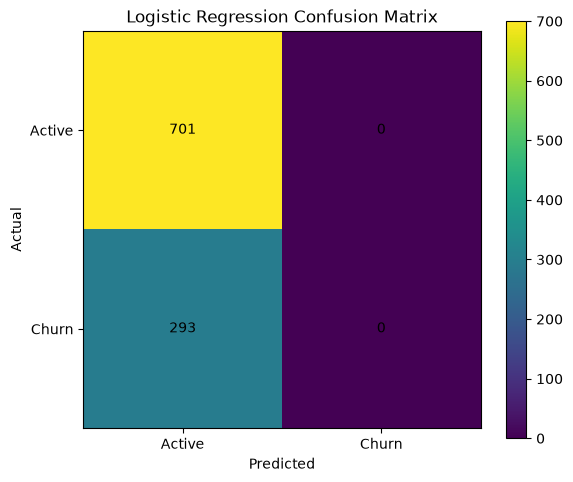

In [132]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_logistic)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Active", "Churn"])
plt.yticks([0, 1], ["Active", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_logistic[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [133]:
X_train
X_test

,total_orders_x,total_spending_x,average_order_value_x,average_discount_x,total_quantity_x,unique_products_x,unique_categories_x,historical_recency_x,average_profit_x,total_orders_y,total_spending_y,average_order_value_y,average_discount_y,total_quantity_y,unique_products_y,unique_categories_y,historical_recency_y,average_profit_y
1663,8,808665.3260,101083.165750,0.117500,44,19,5,23,9925.257300,8,808665.3260,101083.165750,0.117500,44,19,5,23,9925.257300
1351,4,427776.4540,106944.113500,0.093750,23,8,4,87,8616.654250,4,427776.4540,106944.113500,0.093750,23,8,4,87,8616.654250
265,7,830352.0400,118621.720000,0.100000,30,11,5,7,20900.356364,7,830352.0400,118621.720000,0.100000,30,11,5,7,20900.356364
4322,3,467145.2605,155715.086833,0.085714,17,7,4,332,18808.917214,3,467145.2605,155715.086833,0.085714,17,7,4,332,18808.917214
3452,6,702168.9270,117028.154500,0.123333,38,14,4,193,8015.475133,6,702168.9270,117028.154500,0.123333,38,14,4,193,8015.475133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4876,4,329501.6185,82375.404625,0.150000,16,7,2,10,8283.149786,4,329501.6185,82375.404625,0.150000,16,7,2,10,8283.149786
2155,7,979459.6300,139922.804286,0.110526,51,19,4,120,9395.663158,7,979459.6300,139922.804286,0.110526,51,19,4,120,9395.663158
4288,3,433649.8290,144549.943000,0.087500,22,8,4,77,13333.946125,3,433649.8290,144549.943000,0.087500,22,8,4,77,13333.946125
3818,3,254500.1920,84833.397333,0.108333,15,6,4,396,9067.985333,3,254500.1920,84833.397333,0.108333,15,6,4,396,9067.985333


In [134]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [135]:
rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [136]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_probabilities
    )
)

Accuracy: 0.6167002012072434
Precision: 0.29245283018867924
Recall: 0.21160409556313994
F1 Score: 0.24554455445544554
ROC-AUC: 0.4916087695296334


In [137]:
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.70      0.79      0.74       701
           1       0.29      0.21      0.25       293

    accuracy                           0.62       994
   macro avg       0.50      0.50      0.49       994
weighted avg       0.58      0.62      0.60       994



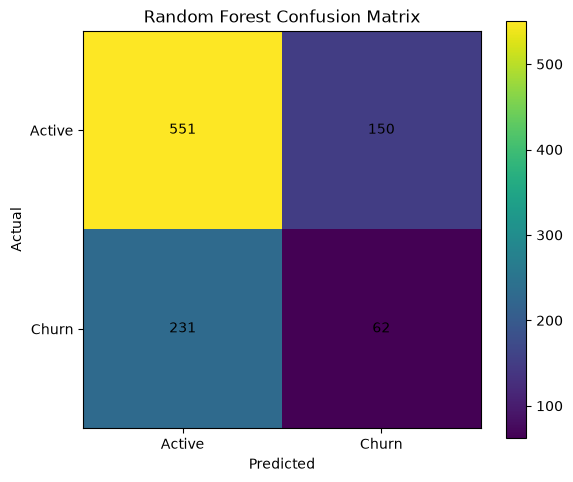

In [138]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_rf)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Active", "Churn"])
plt.yticks([0, 1], ["Active", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [139]:
gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [140]:
gradient_model.fit(
    X_train,
    y_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [141]:
gb_predictions = gradient_model.predict(
    X_test
)

gb_probabilities = gradient_model.predict_proba(
    X_test
)[:, 1]

In [142]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        gb_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        gb_predictions,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        gb_predictions,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        gb_predictions,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        gb_probabilities
    )
)

Accuracy: 0.7012072434607646
Precision: 0.16666666666666666
Recall: 0.0034129692832764505
F1 Score: 0.006688963210702341
ROC-AUC: 0.5080966732069739


In [143]:
print(
    classification_report(
        y_test,
        gb_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.70      0.99      0.82       701
           1       0.17      0.00      0.01       293

    accuracy                           0.70       994
   macro avg       0.44      0.50      0.42       994
weighted avg       0.55      0.70      0.58       994



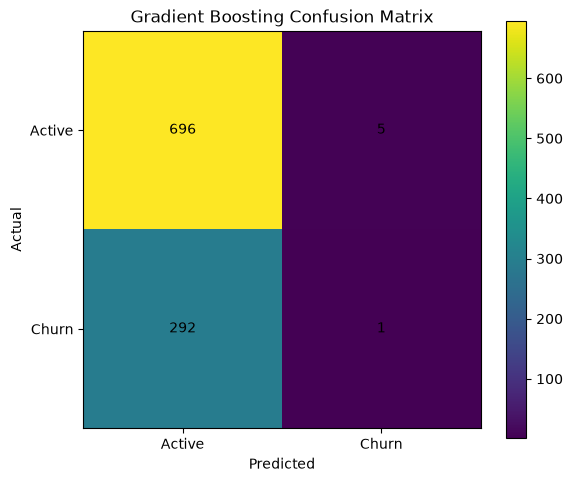

In [144]:
cm_gb = confusion_matrix(
    y_test,
    gb_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_gb)

plt.title("Gradient Boosting Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Active", "Churn"])
plt.yticks([0, 1], ["Active", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_gb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [145]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            logistic_predictions
        ),
        accuracy_score(
            y_test,
            rf_predictions
        ),
        accuracy_score(
            y_test,
            gb_predictions
        )
    ],

    "Precision": [
        precision_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            rf_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            gb_predictions,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            rf_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            gb_predictions,
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            rf_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            gb_predictions,
            zero_division=0
        )
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_probabilities
        ),
        roc_auc_score(
            y_test,
            rf_probabilities
        ),
        roc_auc_score(
            y_test,
            gb_probabilities
        )
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.705231,0.000000,0.000000,0.000000,0.527808
1,Random Forest,0.616700,0.292453,0.211604,0.245545,0.491609
2,Gradient Boosting,0.701207,0.166667,0.003413,0.006689,0.508097


In [146]:
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7052,0.0000,0.0000,0.0000,0.5278
1,Random Forest,0.6167,0.2925,0.2116,0.2455,0.4916
2,Gradient Boosting,0.7012,0.1667,0.0034,0.0067,0.5081


In [147]:
best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: Random Forest


<Figure size 800x600 with 0 Axes>

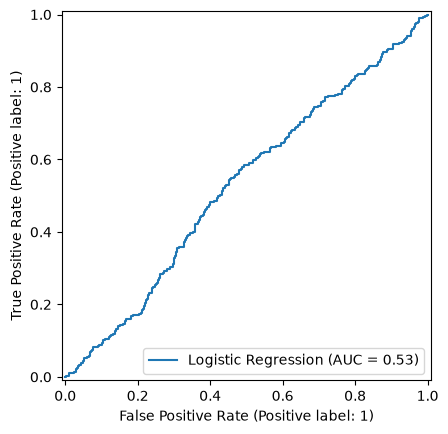

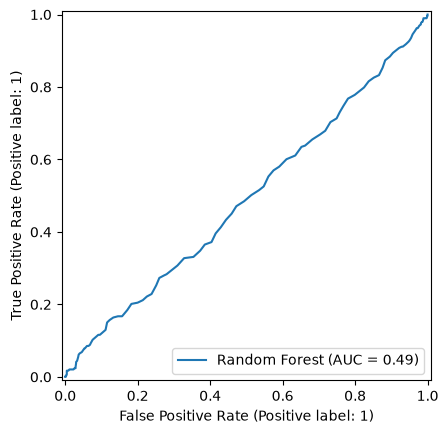

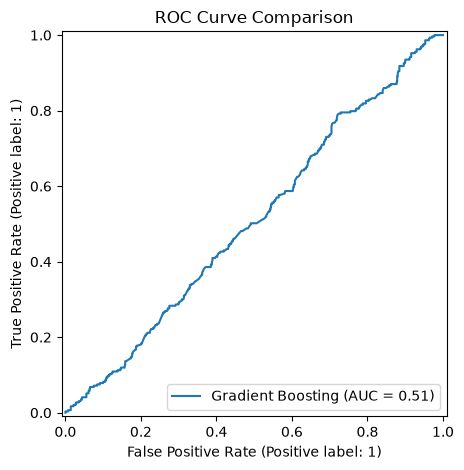

In [148]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    gb_probabilities,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.tight_layout()
plt.show()

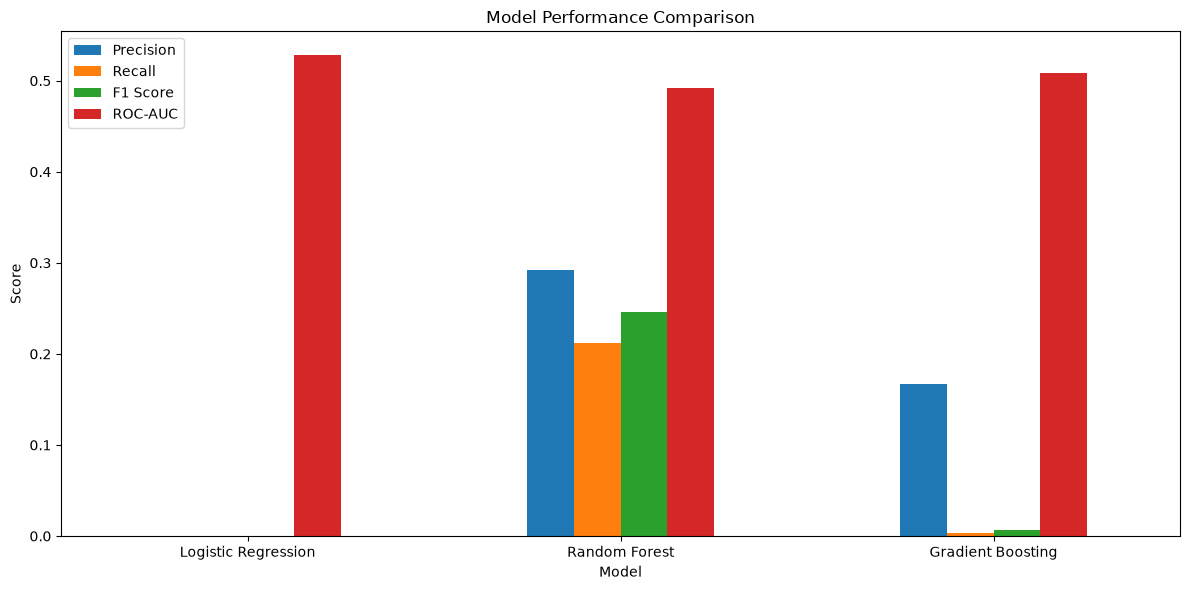

In [149]:
performance_plot = model_results.set_index("Model")

performance_plot[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [150]:
BASE_DIR = os.path.abspath("..")

model_results.to_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "model_comparison.csv"
    ),
    index=False
)

print("Model comparison saved successfully!")

print("Model comparison saved successfully!")

Model comparison saved successfully!
Model comparison saved successfully!


# Step 29 — Model Interpretation and Final Model

In [45]:
import joblib

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,average_profit,0.120184
11,historical_recency,0.116415
2,average_order_value_x,0.101482
6,average_order_value_y,0.101086
5,total_spending_y,0.096565
1,total_spending_x,0.096054
7,average_discount_y,0.083920
3,average_discount_x,0.082501
8,total_quantity,0.081220
9,unique_products,0.054465


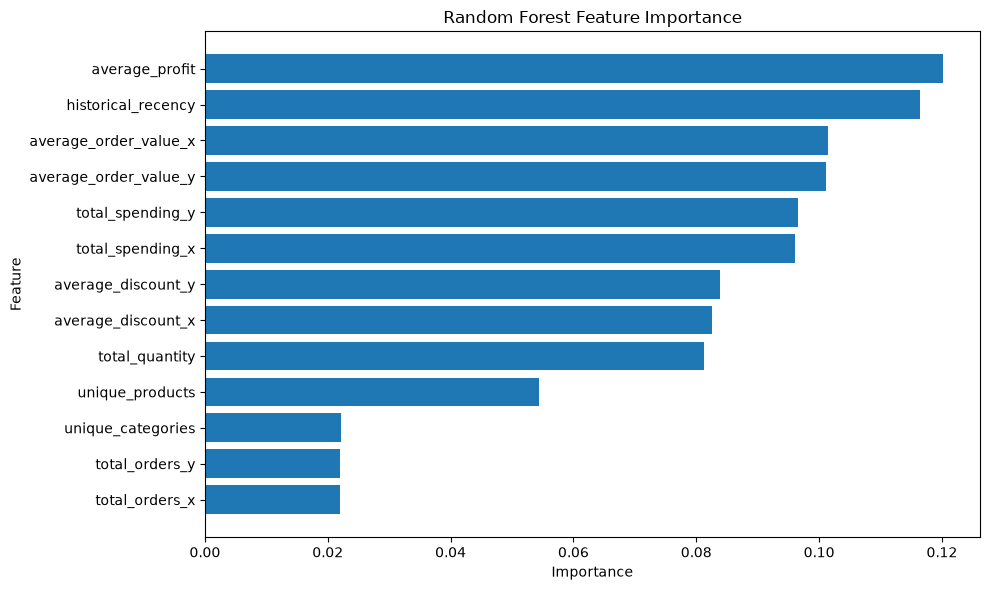

In [47]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [48]:
gb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gradient_model.feature_importances_
})

gb_feature_importance = gb_feature_importance.sort_values(
    "Importance",
    ascending=False
)

gb_feature_importance

,Feature,Importance
12,average_profit,0.238884
11,historical_recency,0.111802
1,total_spending_x,0.107063
2,average_order_value_x,0.104638
5,total_spending_y,0.098727
6,average_order_value_y,0.086860
7,average_discount_y,0.071676
8,total_quantity,0.059190
3,average_discount_x,0.053926
9,unique_products,0.036949


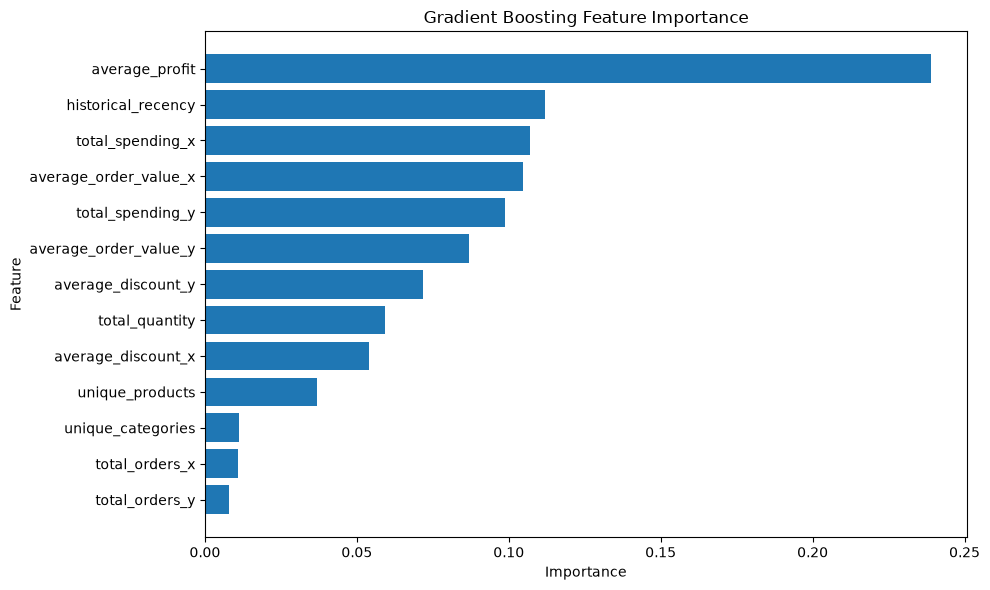

In [49]:
plt.figure(figsize=(10, 6))

plt.barh(
    gb_feature_importance["Feature"],
    gb_feature_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [50]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

In [51]:
threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,threshold,precision,recall,f1_score
0,0.10,0.294769,1.000000,0.455322
1,0.15,0.295732,0.993174,0.455756
2,0.20,0.292100,0.959044,0.447809
3,0.25,0.291898,0.897611,0.440536
4,0.30,0.289571,0.805461,0.425993
5,0.35,0.292609,0.662116,0.405858
6,0.40,0.294355,0.498294,0.370089
7,0.45,0.297688,0.351536,0.322379
8,0.50,0.298165,0.221843,0.254403
9,0.55,0.342105,0.133106,0.191646


In [52]:
best_threshold = threshold_results.loc[
    threshold_results["f1_score"].idxmax(),
    "threshold"
]

print(
    "Best threshold:",
    best_threshold
)

Best threshold: 0.15000000000000002


In [53]:
threshold_results.loc[
    threshold_results["f1_score"].idxmax()
]

threshold    0.150000
precision    0.295732
recall       0.993174
f1_score     0.455756
Name: 1, dtype: float64

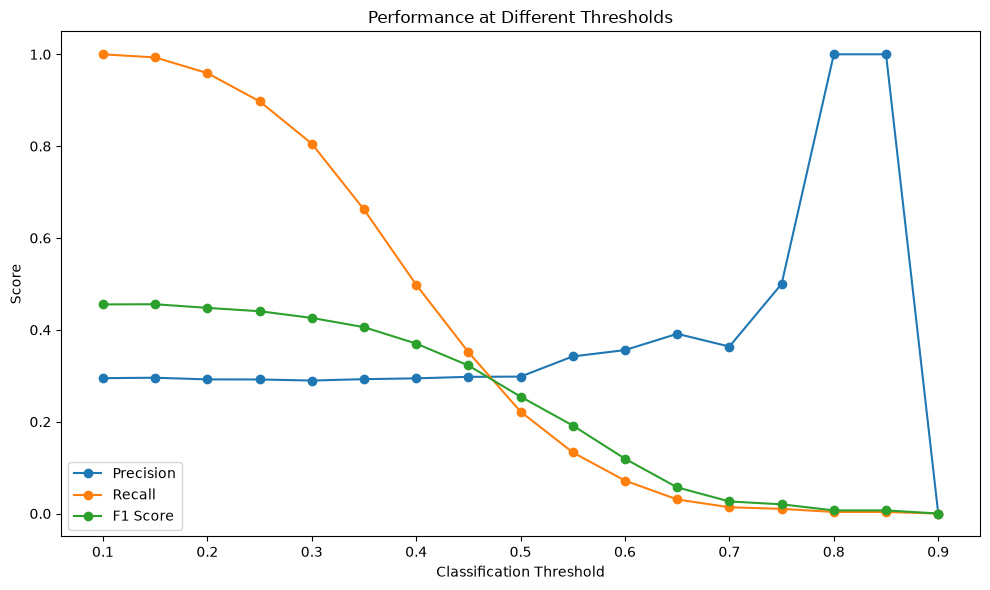

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1_score"],
    marker="o",
    label="F1 Score"
)

plt.title("Performance at Different Thresholds")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.legend()

plt.tight_layout()
plt.show()

In [55]:
final_predictions = (
    rf_probabilities >= best_threshold
).astype(int)

In [56]:
print(
    "Precision:",
    precision_score(
        y_test,
        final_predictions,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        final_predictions,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        final_predictions,
        zero_division=0
    )
)

Precision: 0.29573170731707316
Recall: 0.9931740614334471
F1 Score: 0.4557556773688332


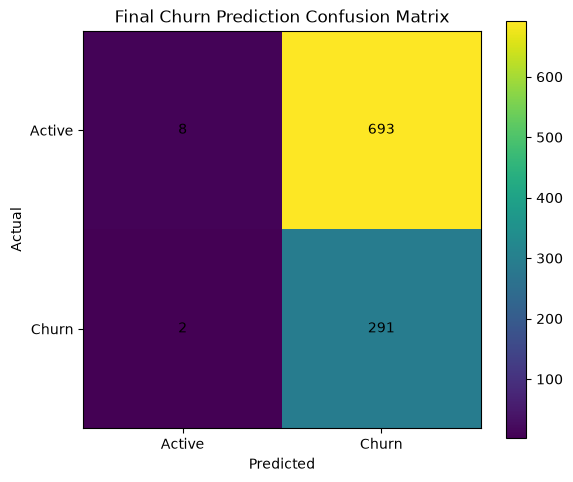

In [57]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title("Final Churn Prediction Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Active", "Churn"]
)

plt.yticks(
    [0, 1],
    ["Active", "Churn"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [58]:
model_results.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.616700,0.298165,0.221843,0.254403,0.497040
2,Gradient Boosting,0.701207,0.166667,0.003413,0.006689,0.505516
0,Logistic Regression,0.705231,0.000000,0.000000,0.000000,0.527788


In [59]:
best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

print(
    "Selected Model:",
    best_model_name
)

Selected Model: Random Forest


In [60]:
if best_model_name == "Logistic Regression":
    
    final_model = logistic_model
    final_probabilities = logistic_probabilities

elif best_model_name == "Random Forest":
    
    final_model = random_forest_model
    final_probabilities = rf_probabilities

elif best_model_name == "Gradient Boosting":
    
    final_model = gradient_model
    final_probabilities = gb_probabilities

In [61]:
print(
    "Final model:",
    best_model_name
)

Final model: Random Forest


In [62]:
MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

In [63]:
joblib.dump(
    final_model,
    os.path.join(
        MODEL_DIR,
        "churn_prediction_model.pkl"
    )
)

['d:\\ds1\\models\\churn_prediction_model.pkl']

In [64]:
print("Model saved successfully!")

Model saved successfully!


In [65]:
joblib.dump(
    scaler,
    os.path.join(
        MODEL_DIR,
        "feature_scaler.pkl"
    )
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [66]:
feature_names = list(
    X_train.columns
)

joblib.dump(
    feature_names,
    os.path.join(
        MODEL_DIR,
        "feature_names.pkl"
    )
)

['d:\\ds1\\models\\feature_names.pkl']

In [67]:
prediction_results = X_test.copy()

prediction_results["actual_churn"] = (
    y_test.values
)

prediction_results["churn_probability"] = (
    final_probabilities
)

In [68]:
prediction_results["predicted_churn"] = (
    final_probabilities >= best_threshold
).astype(int)

In [69]:
prediction_results["customer_id"] = (
    ml_data.loc[
        X_test.index,
        "customer_id"
    ].values
)

In [70]:
prediction_results = prediction_results[
    [
        "customer_id",
        "actual_churn",
        "predicted_churn",
        "churn_probability"
    ]
]

In [71]:
prediction_results.head(10)

,customer_id,actual_churn,predicted_churn,churn_probability
1663,4180,0,1,0.525
1351,4975,0,1,0.280
265,3294,0,1,0.435
4322,4177,0,1,0.320
3452,1933,0,1,0.295
3475,3362,0,1,0.295
4278,4055,0,1,0.420
1890,1341,0,1,0.485
423,3468,0,1,0.505
4944,1610,1,1,0.315


In [72]:
def risk_category(probability):

    if probability >= 0.75:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [73]:
prediction_results["risk_category"] = (
    prediction_results["churn_probability"]
    .apply(risk_category)
)

In [74]:
prediction_results.head(10)

,customer_id,actual_churn,predicted_churn,churn_probability,risk_category
1663,4180,0,1,0.525,Medium Risk
1351,4975,0,1,0.280,Low Risk
265,3294,0,1,0.435,Medium Risk
4322,4177,0,1,0.320,Low Risk
3452,1933,0,1,0.295,Low Risk
3475,3362,0,1,0.295,Low Risk
4278,4055,0,1,0.420,Medium Risk
1890,1341,0,1,0.485,Medium Risk
423,3468,0,1,0.505,Medium Risk
4944,1610,1,1,0.315,Low Risk


In [75]:
prediction_results.sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customer_id,actual_churn,predicted_churn,churn_probability,risk_category
4931,2235,1,1,0.880,High Risk
1992,1518,1,1,0.775,High Risk
3708,4900,1,1,0.770,High Risk
1485,127,0,1,0.765,High Risk
2444,3527,0,1,0.760,High Risk
2403,786,0,1,0.760,High Risk
2301,1570,1,1,0.735,Medium Risk
127,4007,0,1,0.725,Medium Risk
4175,315,0,1,0.715,Medium Risk
3573,355,0,1,0.710,Medium Risk


In [76]:
prediction_results.to_csv(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "churn_predictions.csv"
    ),
    index=False
)

print("Churn predictions saved successfully!")

Churn predictions saved successfully!


In [151]:
joblib.dump(
    float(best_threshold),
    os.path.join(
        MODEL_DIR,
        "best_threshold.pkl"
    )
)

['d:\\ds1\\models\\best_threshold.pkl']